In [2]:
# Packages
import numpy as np
import pandas as pd

# Load Palmer penguins data
URL = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv'
penguins = pd.read_csv(URL)

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


**SUMMARY STATISTICS**

It is easy to get summary statistics for each column in a pandas.DataFrame by using methods such as:

`sum()`: sum values in each column,
`count()`: count non-NA values in each column,
`size()`: count the number of values in a column (including NA values),
`min()` and `max()`: get the minimum and maximum value in each column,
`mean()` and `median()`: get the mean and median value in each column,
`std()` and `var()`: get the standard deviation and variance in each column.

In [3]:
# Get the number of non-NA values in each column 
penguins.count()

species              344
island               344
bill_length_mm       342
bill_depth_mm        342
flipper_length_mm    342
body_mass_g          342
sex                  333
year                 344
dtype: int64

In [4]:
# Get the minimum value in each column with numerical values
penguins.select_dtypes('number').min()

bill_length_mm         32.1
bill_depth_mm          13.1
flipper_length_mm     172.0
body_mass_g          2700.0
year                 2007.0
dtype: float64

**GROUPING**
Penguins data is naturally split into different groups: three different species, two sexes (with some NA), and three islands. 

To calculate (for example) the average flipper length per species, we would use the Split-Apply_Combine strategy:
1. Split: Split the data into logical groups (e.g. species, sex, island)
2. Apply: Calculate some summary statistic on each group (e.g. average flipper length by species)
3. Combine: Combine the statistic calculated on each group back together

For a `pandas.DataFrame` or `pandas.Series`, we can use the `groupby()` method to split (i.e. group) the data into different categories.

General syntax for `groupby()`:

```python
df.groupby(columns_to_group_by).summary_method()
```

Most often, `columns_to_group_by` is a single column name (a string) or a list of column names. The unique values of the column (or columns) will be used as the groups of the data frame. 

If we don't use `groupby()` and directly apply the `mean()` method to our flipper length column, we obtain the average of all the values in the column:

In [5]:
penguins['flipper_length_mm'].mean()

200.91520467836258

To get the mean flipper length by species we first group our dataset by the species column's values. However, if we just use the `groupby()` method without specifying what we wish to calculate on each group, not much happens up front: 

In [6]:
penguins.groupby('species')['flipper_length_mm']

We get a `Groupby` object, which is an intermediate step. It doesn't perform the actual calculations until we specify an operation:

In [7]:
# Average flipper length per species
penguins.groupby('species')['flipper_length_mm'].mean()

species
Adelie       189.953642
Chinstrap    195.823529
Gentoo       217.186992
Name: flipper_length_mm, dtype: float64

NOTE: when reading a line of code, the . can be read as "and then..."

```python
penguins.groupby('species')['flipper_length_mm'].mean()
```
This line says: 
1. Start with the `penguins` data frame, and then...
2. Use `groupby()` to group the data frame by `species` values, and then ...
3. Select the `'flipper_length_mm'` column, and then ...
4. Calculate the `mean()` of this colmn with respect to the groups.

In [8]:
# Average flipper length per species
avg_flipper = (penguins.groupby('species')
                          ['flipper_length_mm']
                          .mean()
                          .rename('mean_flipper_length')
                          .sort_values(ascending=False)
                          )
avg_flipper

species
Gentoo       217.186992
Chinstrap    195.823529
Adelie       189.953642
Name: mean_flipper_length, dtype: float64

In [9]:
# Average flipper length per species and island
avg_flipper_species_island = (penguins.groupby(['species','island'])
                             ['flipper_length_mm']
                             .mean()
                             .rename('mean_flipper_length')
                             .sort_values(ascending=False)
                             )
avg_flipper_species_island

species    island   
Gentoo     Biscoe       217.186992
Chinstrap  Dream        195.823529
Adelie     Torgersen    191.196078
           Dream        189.732143
           Biscoe       188.795455
Name: mean_flipper_length, dtype: float64

**GROUPING AND NA VALUES**
11 penguins have no recorded sex. We can check this using: 

`size`: returns the number of observations in a pandas.Series
`count()`: returns the number of non-NA observations in the series

In [12]:
# pandas.Series of sex column in penguins data frame
penguins['sex']

0        male
1      female
2      female
3         NaN
4      female
        ...  
339      male
340    female
341      male
342      male
343    female
Name: sex, Length: 344, dtype: object

In [13]:
# Number of observations in the series
penguins['sex'].size

344

In [14]:
# Number of non-NA observations in the series
penguins['sex'].count()

333

In [10]:
# Number of NA observations 
penguins['sex'].size - penguins['sex'].count()

11

By default, `groupby()` leaves out the rows where the grouping column has NA values. When we group by `sex` and count the number of observations (rows) we are left with: 

In [15]:
penguins.groupby('sex').size()

sex
female    165
male      168
dtype: int64

To keep the NA values as their own group, we use the `dropna=False` parameter:

In [16]:
penguins.groupby('sex', dropna=False).size()

sex
female    165
male      168
NaN        11
dtype: int64

Check-in:
We are interested in knowing the number of penguins surveyed on each island in different years. Run:
```python
penguins.groupby(['island','year']).count()
```
and
```python
penguins.groupby(['island','year']).size()
```
Discuss the differences between each output. What method would give you the number of penguins surveyed on each island and year combination?

In [23]:
penguins.groupby(['island','year']).count()

species  bill_length_mm  bill_depth_mm  flipper_length_mm  \
island    year                                                              
Biscoe    2007       44              44             44                 44   
          2008       64              64             64                 64   
          2009       60              59             59                 59   
Dream     2007       46              46             46                 46   
          2008       34              34             34                 34   
          2009       44              44             44                 44   
Torgersen 2007       20              19             19                 19   
          2008       16              16             16                 16   
          2009       16              16             16                 16   

                body_mass_g  sex  
island    year                    
Biscoe    2007           44   43  
          2008           64   63  
          2009           59   57  
Dream     2007           46   45  
          2008           34   34  
          2009           44   44  
Torgersen 2007           19   15  
          2008           16   16  
          2009           16   16

In [22]:
penguins.groupby(['island','year']).size()

island     year
Biscoe     2007    44
           2008    64
           2009    60
Dream      2007    46
           2008    34
           2009    44
Torgersen  2007    20
           2008    16
           2009    16
dtype: int64

`size()` is telling you how many entries there are in general, `count()` is telling you how many entries per column. `size()` returns a pandas.Series and `count()` returns a pandas.DataFrame.

<Axes: title={'center': 'Penguins surveyed at the Palmer Archipelago'}, xlabel='Number of penguins', ylabel='Island, Year'>

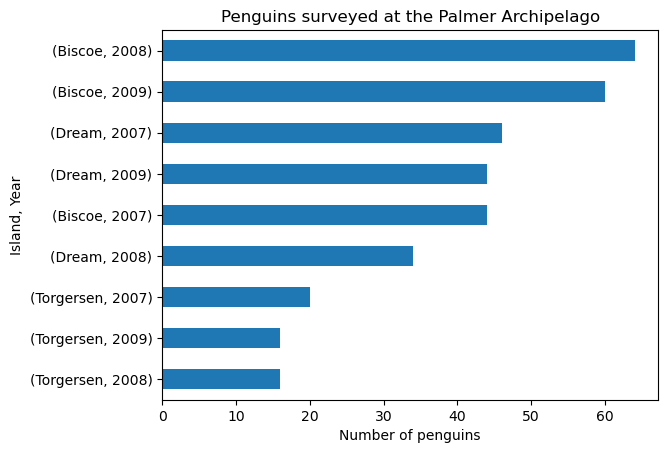

In [24]:
# Method chaining to plot surveyed population per year and island
(penguins.groupby(['island','year'])
         .size()
         .sort_values()
         .plot(kind='barh',
             title='Penguins surveyed at the Palmer Archipelago',
             xlabel='Number of penguins',
             ylabel='Island, Year')
         )

Check-in 1:
Use the `max()` method to calculate the maximum value of a penguin's body mass by year and species.

In [33]:
penguins.groupby(['year','species'])['body_mass_g'].max()

year  species  
2007  Adelie       4675.0
      Chinstrap    4400.0
      Gentoo       6300.0
2008  Adelie       4700.0
      Chinstrap    4800.0
      Gentoo       6000.0
2009  Adelie       4775.0
      Chinstrap    4450.0
      Gentoo       6000.0
Name: body_mass_g, dtype: float64

Check-in 2: 
Use (1) to display the highest body masses per year and species as a bar plot in descending order.

<Axes: title={'center': 'Penguins surveyed at the Palmer Archipelago'}, xlabel='Number of penguins', ylabel='Year, Species'>

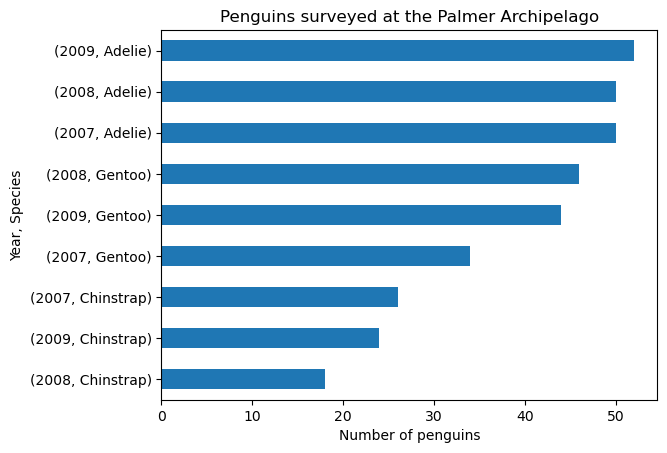

In [35]:
(penguins.groupby(['year','species'])['body_mass_g']
         .size()
         .sort_values()
         .plot(kind='barh',
              title='Penguins surveyed at the Palmer Archipelago',
              xlabel='Number of penguins',
              ylabel='Year, Species')
)